# Stellar Luminosity – Regresión Lineal (M)

Objective: Modelar L como función de M con L_hat = w*M + b.

Required tasks: Dataset visualization, Model/Loss, Cost surface, Gradients,
GD (no vectorizado y vectorizado), Convergence, Experiments, Final fit, Conceptual.

## Importar Bibliotecas Necesarias

In [66]:
# Importar Bibliotecas Necesarias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # habilitar proyección 3D
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Definir el Dataset (M, L)

In [67]:
# Definir el Dataset (Masa vs Luminosidad)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])
print(f"n muestras: {M.size}")

n muestras: 10


## 1) Dataset visualization

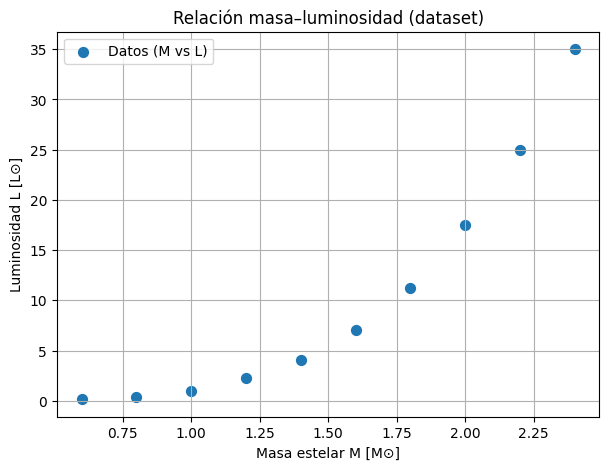

In [68]:
# Visualización del Dataset
plt.scatter(M, L, c='tab:blue', s=50, label='Datos (M vs L)')
plt.xlabel('Masa estelar M [M⊙]')
plt.ylabel('Luminosidad L [L⊙]')
plt.title('Relación masa–luminosidad (dataset)')
plt.legend()
plt.show()

## 2) Model and loss

In [69]:
# Definir hipótesis y pérdida (MSE)
def predict(M, w, b):
    return w * M + b

def mse(y_hat, y):
    return np.mean((y_hat - y)**2)

# Probar funciones
w0, b0 = 1.0, 0.0
L_hat0 = predict(M, w0, b0)
print("MSE(w=1,b=0):", mse(L_hat0, L))

MSE(w=1,b=0): 194.9275


## 3) Cost surface (mandatory)

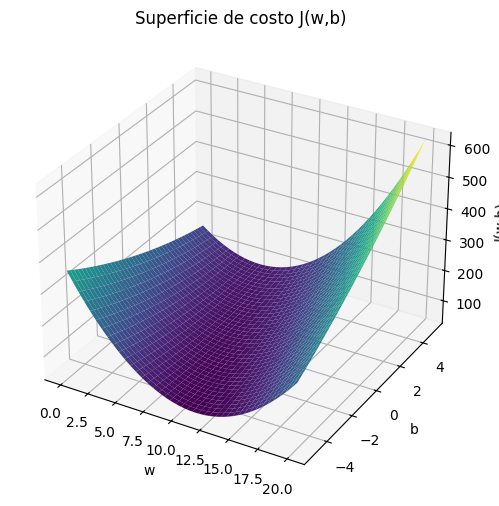

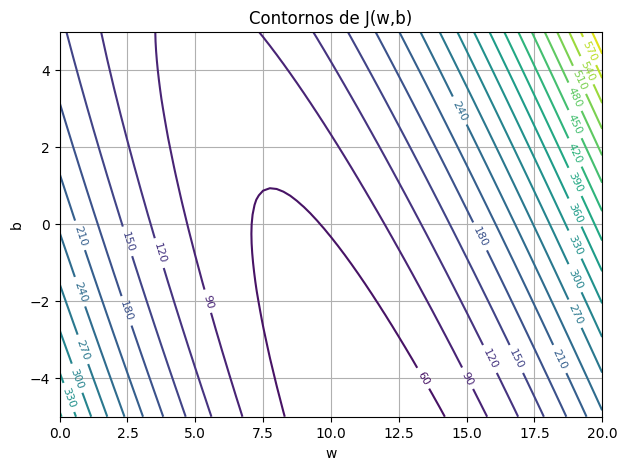

In [70]:
# Superficie de costo J(w,b)
ws = np.linspace(0.0, 20.0, 81)
bs = np.linspace(-5.0, 5.0, 41)
J = np.zeros((ws.size, bs.size))
for i, w in enumerate(ws):
    for j, b in enumerate(bs):
        J[i, j] = mse(predict(M, w, b), L)

Wg, Bg = np.meshgrid(ws, bs, indexing='ij')
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Wg, Bg, J, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('J(w,b)')
ax.set_title('Superficie de costo J(w,b)')
plt.show()

plt.figure()
cs = plt.contour(Wg, Bg, J, levels=20, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel('w')
plt.ylabel('b')
plt.title('Contornos de J(w,b)')
plt.show()

### 4) Gradients: dJ/dw y dJ/db
Derivamos y codificamos los gradientes de MSE. Proporcionamos versión no vectorizada y vectorizada.

In [71]:
# Derivar e implementar gradientes
# Para MSE = (1/n) \sum (w*M_i + b - L_i)^2
# dJ/dw = (2/n) \sum M_i * (w*M_i + b - L_i)
# dJ/db = (2/n) \sum (w*M_i + b - L_i)

def gradients_no_vectorized(M, L, w, b):
    n = M.size
    dw = 0.0
    db = 0.0
    for i in range(n):
        err = (w * M[i] + b) - L[i]
        dw += M[i] * err
        db += err
    dw *= 2.0 / n
    db *= 2.0 / n
    return dw, db

# Versión vectorizada
# usando err = w*M + b - L y sumas con NumPy
def gradients_vectorized(M, L, w, b):
    n = M.size
    err = (w * M + b) - L
    dw = (2.0 / n) * np.sum(M * err)
    db = (2.0 / n) * np.sum(err)
    return dw, db

### 5) Gradient descent (non-vectorized)
Entrenamos usando un loop explícito sobre las muestras para calcular gradientes.

In [72]:
# Gradient Descent (no vectorizado)
def gradient_descent_no_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=500):
    w, b = w_init, b_init
    losses = []
    for t in range(iterations):
        y_hat = predict(M, w, b)
        losses.append(mse(y_hat, L))
        dw, db = gradients_no_vectorized(M, L, w, b)
        w -= alpha * dw
        b -= alpha * db
    return w, b, np.array(losses)

w_nv, b_nv, losses_nv = gradient_descent_no_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=300)
print(f"No vectorizado: w={w_nv:.4f}, b={b_nv:.4f}, loss final={losses_nv[-1]:.6f}")

No vectorizado: w=11.1712, b=-5.3050, loss final=36.829087


### 6) Gradient descent (vectorized)
Entrenamos usando gradientes con operaciones vectorizadas de NumPy (sin loops por muestra).

In [73]:
# Gradient Descent (vectorizado)
def gradient_descent_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=500):
    w, b = w_init, b_init
    losses = []
    for t in range(iterations):
        err = (w * M + b) - L
        losses.append(np.mean(err**2))
        # Gradientes vectorizados
        n = M.size
        dw = (2.0 / n) * np.sum(M * err)
        db = (2.0 / n) * np.sum(err)
        w -= alpha * dw
        b -= alpha * db
    return w, b, np.array(losses)

w_v, b_v, losses_v = gradient_descent_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=300)
print(f"Vectorizado: w={w_v:.4f}, b={b_v:.4f}, loss final={losses_v[-1]:.6f}")

Vectorizado: w=11.1712, b=-5.3050, loss final=36.829087


### 7-8) Convergence (mandatory)
Graficamos MSE vs iteraciones para analizar velocidad de convergencia y estabilidad del entrenamiento. Ejecutamos al menos tres learning rates y reportamos los valores finales de `w`, `b` y la pérdida (MSE).

alpha=0.001: w=6.7749, b=1.5793, loss final=64.070048
alpha=0.01: w=13.3669, b=-8.9431, loss final=27.666975
alpha=0.05: w=18.0247, b=-16.6605, loss final=19.594328


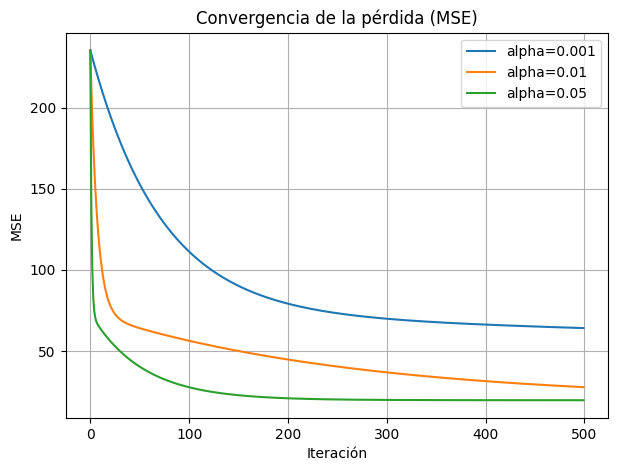

In [74]:
# Experimentos con diferentes learning rates y visualización de convergencia
learning_rates = [0.001, 0.01, 0.05]
results = {}
iterations = 500
for alpha in learning_rates:
    w_e, b_e, losses_e = gradient_descent_vec(M, L, w_init=0.0, b_init=0.0, alpha=alpha, iterations=iterations)
    results[alpha] = (w_e, b_e, losses_e)
    print(f"alpha={alpha}: w={w_e:.4f}, b={b_e:.4f}, loss final={losses_e[-1]:.6f}")

plt.figure()
for alpha in learning_rates:
    plt.plot(results[alpha][2], label=f"alpha={alpha}")
plt.xlabel('Iteración')
plt.ylabel('MSE')
plt.title('Convergencia de la pérdida (MSE)')
plt.legend()
plt.show()

In [75]:
# Resumen de resultados de los experimentos
for alpha in learning_rates:
    w_e, b_e, losses_e = results[alpha]
    print(f"alpha={alpha:>6}  w={w_e:8.4f}  b={b_e:8.4f}  loss_final={losses_e[-1]:.6f}")

alpha= 0.001  w=  6.7749  b=  1.5793  loss_final=64.070048
alpha=  0.01  w= 13.3669  b= -8.9431  loss_final=27.666975
alpha=  0.05  w= 18.0247  b=-16.6605  loss_final=19.594328


### 9) Final fit plot
Graficamos la línea de regresión final sobre los datos y discutimos errores sistemáticos.

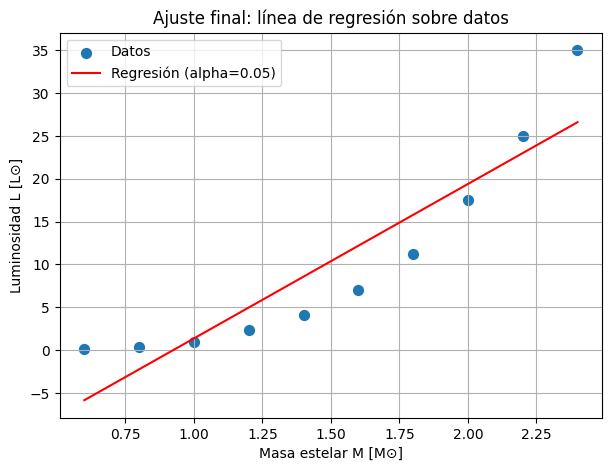

Discusión: La línea captura la tendencia general, pero tiende a subestimar las lumin.
Para masas mayores, la relación real es fuertemente no lineal (p.ej., ~M^3–M^4 en la secuencia principal).


In [76]:
# Línea de regresión final y discusión
# Tomemos el mejor alpha por menor loss final
best_alpha = min(learning_rates, key=lambda a: results[a][2][-1])
w_best, b_best, losses_best = results[best_alpha]

plt.scatter(M, L, c='tab:blue', s=50, label='Datos')
M_line = np.linspace(M.min(), M.max(), 100)
L_line = predict(M_line, w_best, b_best)
plt.plot(M_line, L_line, 'r-', label=f'Regresión (alpha={best_alpha})')
plt.xlabel('Masa estelar M [M⊙]')
plt.ylabel('Luminosidad L [L⊙]')
plt.title('Ajuste final: línea de regresión sobre datos')
plt.legend()
plt.show()

print("Discusión: La línea captura la tendencia general, pero tiende a subestimar las lumin.")
print("Para masas mayores, la relación real es fuertemente no lineal (p.ej., ~M^3–M^4 en la secuencia principal).")

### 10) Conceptual questions
- Astrophysical meaning of w: En `L_hat = w*M + b`, `w` captura la sensibilidad de la luminosidad a cambios en la masa.
- Why is a linear model limited here?: La relación masa–luminosidad típica es de ley de potencia (≈ M^3–M^4). Un modelo lineal no reproduce bien esta no linealidad, sobre todo a altas masas.